Linear Fit
MSE: 6.221127700282908
R2: 0.13806540751324892

Cubic Polynomial Fit
MSE: 5.294326102194707
R2: 0.2664733740830231

Polynomial fit is better


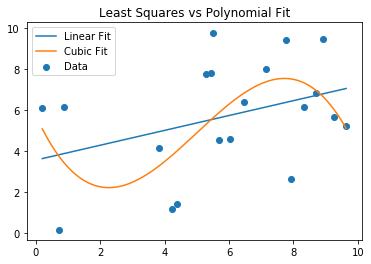

In [8]:
import numpy as np
import matplotlib.pyplot as plt

# Random data
np.random.seed(0)
X = np.random.rand(20) * 10
Y = np.random.rand(20) * 10

idx = np.argsort(X)
X = X[idx]
Y = Y[idx]

A = np.vstack([X, np.ones(len(X))]).T
m, c = np.linalg.lstsq(A, Y, rcond=None)[0]

y_linear = m*X + c

poly_coeff = np.polyfit(X, Y, 3)
poly = np.poly1d(poly_coeff)

y_poly = poly(X)


def MSE(y_true, y_pred):
    return np.mean((y_true - y_pred)**2)

def R2(y_true, y_pred):
    ss_res = np.sum((y_true - y_pred)**2)
    ss_tot = np.sum((y_true - np.mean(y_true))**2)
    return 1 - (ss_res/ss_tot)

mse_linear = MSE(Y, y_linear)
r2_linear = R2(Y, y_linear)

mse_poly = MSE(Y, y_poly)
r2_poly = R2(Y, y_poly)

print("Linear Fit")
print("MSE:", mse_linear)
print("R2:", r2_linear)

print("\nCubic Polynomial Fit")
print("MSE:", mse_poly)
print("R2:", r2_poly)


if mse_linear < mse_poly:
    print("\nLinear fit is better")
else:
    print("\nPolynomial fit is better")

# Plot
x_plot = np.linspace(min(X), max(X), 200)
plt.scatter(X,Y,label="Data")
plt.plot(x_plot, m*x_plot + c,label="Linear Fit")
plt.plot(x_plot, np.poly1d(poly_coeff)(x_plot),label="Cubic Fit")
plt.legend()
plt.title("Least Squares vs Polynomial Fit")
plt.show()

In [10]:
for degree in range(1,10):

    coeffs = np.polyfit(X,Y,degree)
    poly = np.poly1d(coeffs)

    y_pred = poly(X)

    mse = np.mean((Y - y_pred)**2)

    ss_res = np.sum((Y - y_pred)**2)
    ss_tot = np.sum((Y - np.mean(Y))**2)
    r2 = 1 - (ss_res/ss_tot)

    print(f"Degree {degree}: MSE: {mse:.4f}, R2: {r2:.4f}")

Degree 1: MSE: 6.2211, R2: 0.1381
Degree 2: MSE: 6.2211, R2: 0.1381
Degree 3: MSE: 5.2943, R2: 0.2665
Degree 4: MSE: 5.1154, R2: 0.2913
Degree 5: MSE: 5.0991, R2: 0.2935
Degree 6: MSE: 4.8503, R2: 0.3280
Degree 7: MSE: 4.4260, R2: 0.3868
Degree 8: MSE: 3.4787, R2: 0.5180
Degree 9: MSE: 3.2898, R2: 0.5442


In [13]:
degree = 3

# Vandermonde matrix
V = np.vander(X, degree+1)

# Solve coefficients
coeff = np.linalg.lstsq(V, Y, rcond=None)[0]

# Prediction
y_vander = V @ coeff

# Metrics
mse_v = np.mean((Y - y_vander)**2)

ss_res = np.sum((Y - y_vander)**2)
ss_tot = np.sum((Y - np.mean(Y))**2)
r2_v = 1 - (ss_res/ss_tot)

print("Vandermonde Polynomial Fit")
print("MSE=", mse_v)
print("R2=", r2_v)

Vandermonde Polynomial Fit
MSE= 5.294326102194707
R2= 0.2664733740830231
